# **UDTheoretizer**: a library which makes the UD analysis more theoretical

This is a library which works with syntactic analyses produced by UD-based parsers - [spacy-udpipe](https://github.com/TakeLab/spacy-udpipe), [spacy](https://spacy.io/), and [stanza](https://stanfordnlp.github.io/stanza/), - in order to make them more theoretically accurate.

The UD-based parsers have some peculiarities which make them not always suitable for syntacticians: for example, in the [UD notation](https://universaldependencies.org/u/dep/index.html), prepositions are dependents of a nominal, and auxiliary verbs are dependents of lexical verbs, while most theoreticians agree that it is the opposite. The purpose of this module is to reverse these and some other dependencies to produce more accurate results that would be more comfortable to work with.

The UDTheoretizer is quite easy to use - you need to run this cell to load the library:

In [1]:
from UDTheoretizer import UDTheoretizer

After that, you can initialize the parser:

In [2]:
udt = UDTheoretizer()

The default parser that is used is **spacy-udpipe**. The library was originally designed for the Russian language and uses [Russian SynTagRus model](https://github.com/alexeyvkuznetsov/tm_llm_interpretation/blob/main/russian-syntagrus-ud-2.5-191206.udpipe), so the default model is **ru**.

You can specify another language (or another model for your language) in the 'model' argument of UDTheoretizer(). In addition, you may want to specify that you wish to use *spacy* or *stanza* for the parsing and not *spacy-udpipe*, in which case your syntax may be as follows:

In [3]:
# udt2 = UDTheoretizer(parser='spacy', model='ru_core_news_sm')
# udt3 = UDTheoretizer(parser='stanza', model='ru')

During initialization, some warnings may be printed (this mainly concerns *stanza*), which should not scare you. Please keep in mind that *spacy* and *stanza* may work incorrectly more frequently, so we recommend you to stick to the default parser.

**Please make sure that you already have the downloaded model for your language! Otherwise the UDTheoretizer will have nothing to work with and will end up with an error!** The details on the installation of models can be found in the documentation of the corresponding parsers.

The following libraries should be pre-installed as well:
- spacy-udpipe==1.0.0 (in case you are planning to use spacy-udpipe for parsing)
- stanza==1.11.1 (in case you are planning to use stanza for parsing)
- networkx==3.4.2
- matplotlib==3.10.8

After loading the module, you can use it in the following way:

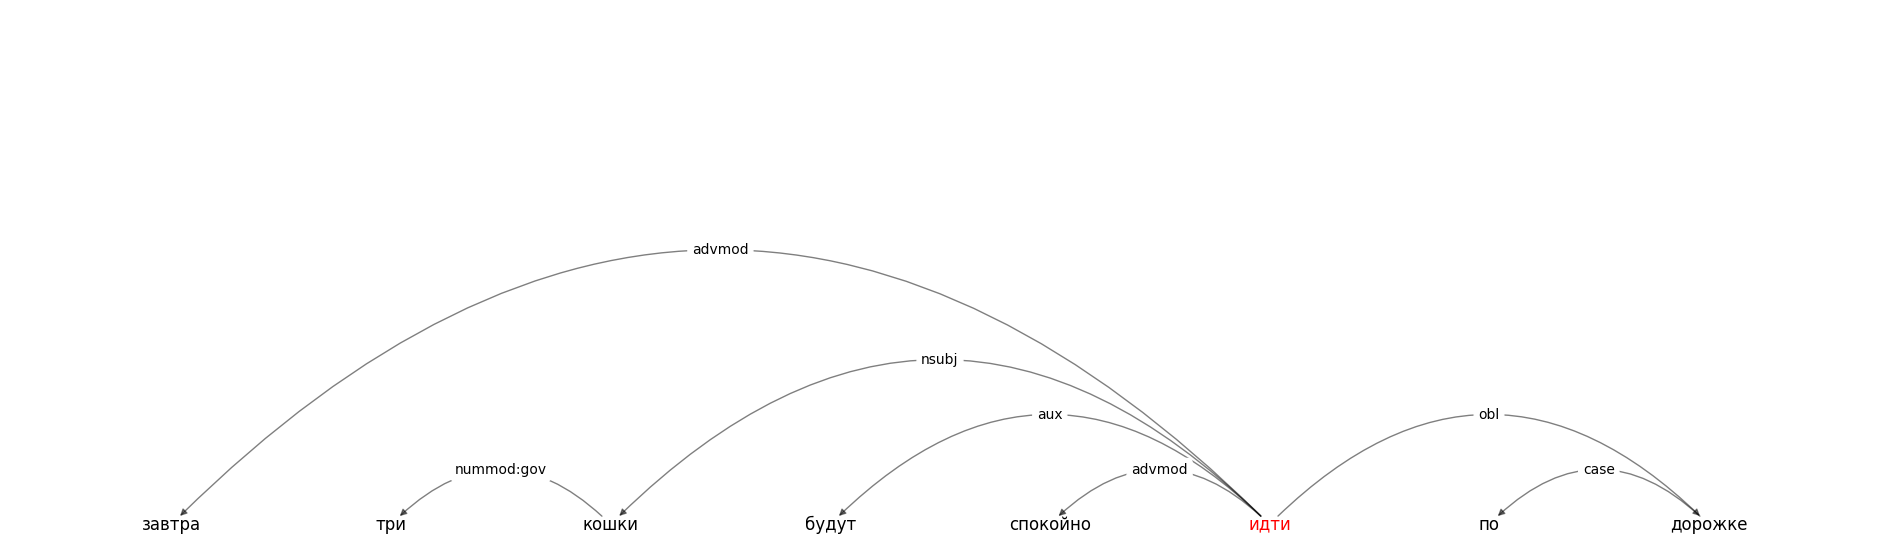

In [4]:
udt.get_original_analysis('завтра три кошки будут спокойно идти по дорожке', out='graph')

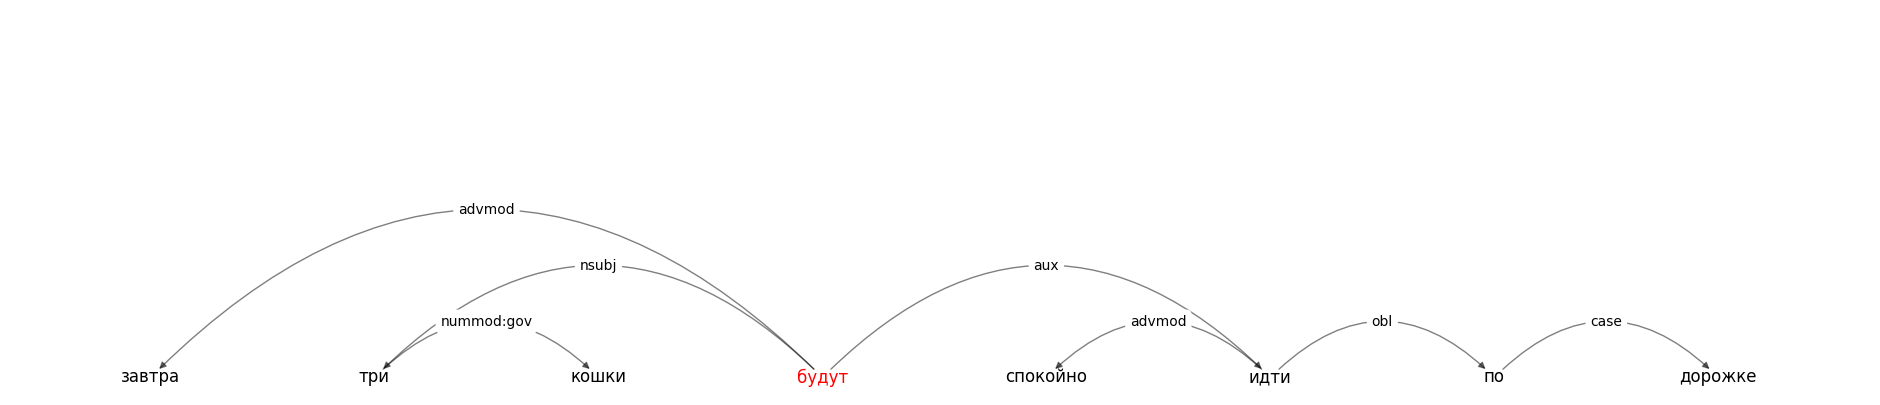

In [5]:
udt.get_theoretical_analysis('завтра три кошки будут спокойно идти по дорожке', out='graph')

The module has two methods - *get_original_analysis* and *get_theoretical_analysis*, with the first one returning the original analysis produced by spacy-udpipe or another parser, and the second one returning a more theoretical analysis. You can also specify the output format in the 'out' argument of each method:
- **dict** (default): returns a list of dictionaries, where features of each word are given as dict attributes;
- **graph**: draws a graph (see the pictures above);
- **doc**: returns a doc object of the same structure as in the original spacy; **this format is not available for stanza!**

As the doc format has the same structure as the output of the original spacy parser, this library is compatible with other spacy functions - for example, with visualizers. See the following demonstration where *displacy* is used for visualization:

In [6]:
from spacy import displacy

doc = udt.get_theoretical_analysis('завтра три кошки будут спокойно идти по дорожке', out='doc')
displacy.render(doc, style='dep', jupyter=True)

The library is currently in development, so something might still be theoretically inaccurate. We are working on the improvement of the library!

Also note that our library was originally meant **for the Russian language** and may not be suitable for other languages, as there might be some cases that we have not taken into account when testing. For example, Russian is different from English in that there are no articles in Russian, which is why it is not agreed whether Russian determiners should be regarded as heads governing nouns; we did not consider them heads, so they are dependents of nominals, though this analysis is not suitable for English and many other languages, so additional changes might be needed to reverse this dependency as well.

Finally, our library is rule-based and does not use any machine learning techniques to improve the parsing, but simply works with the ouput of the existing parser to reverse some dependencies; as such, some errors may occur that are due to the original parsing and that we were not able (but also did not aim to) correct. However, we still hope that this library will help you do syntax more comfortably!